# HI Survey --- Science Products

Load reduced data from `02_scan_load.ipynb` and produce report-ready
figures: reference spectrum, position-velocity diagrams, integrated
intensity and peak velocity maps, and channel maps.

In [55]:
import sys; sys.path.insert(0, '..')

import importlib
if 'utils' in sys.modules:
    del sys.modules['utils']
sys.path.insert(0, '.')

import ugradiolab.plotting as plotting
from ugradiolab.plotting import (SS_FINE, LABEL_SIZE, TICK_SIZE,
                                  EMPHASIS_SIZE, LW_FINE, LW_STANDARD,
                                  ALPHA_STANDARD, ALPHA_LIGHT, ALPHA_FAINT,
                                  NEUTRAL_COLOR, GRID_STYLE)
from plotters import (plot_hi_spectrum, plot_survey_mollweide,
                      plot_heatmap, add_never_observable_overlay)

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

HI_REST_MHZ = 1420.405
C_KMS = 299792.458
MOLL_CENTER_L = 120.0

%matplotlib inline

## 1. Load reduced data

In [56]:
REDUCED_PATH = Path('../reduced_survey.npz')

with np.load(REDUCED_PATH) as f:
    cell_keys = f['cell_keys']        # (N, 2) int: (l, b)
    R_stack = f['R_stack']            # (N, n_ch) float: R(v_LSR)
    v_lsr = f['v_lsr']               # (n_ch,) float
    dv_kms = float(f['dv_kms'])
    n_pairs = f['n_pairs']
    W_flag = f['W_flag']
    peak_v_flag = f['peak_v_flag']
    W = f['W']
    peak_v = f['peak_v']
    snr = f['snr']

gl = cell_keys[:, 0].astype(float)
gb = cell_keys[:, 1].astype(float)
any_flag = W_flag | peak_v_flag
clean = ~any_flag

print(f'Loaded {len(cell_keys)} cells ({clean.sum()} clean, {any_flag.sum()} flagged)')
print(f'Velocity: [{v_lsr[-1]:.0f}, {v_lsr[0]:.0f}] km/s LSR, dv={dv_kms:.3f} km/s')

Loaded 1636 cells (1616 clean, 20 flagged)
Velocity: [-144, 76] km/s LSR, dv=0.528 km/s


## 2. Reference spectrum at (l=120, b=0)

Required by the lab manual for cross-group comparison.

n_pairs = 4, SNR = 14.6


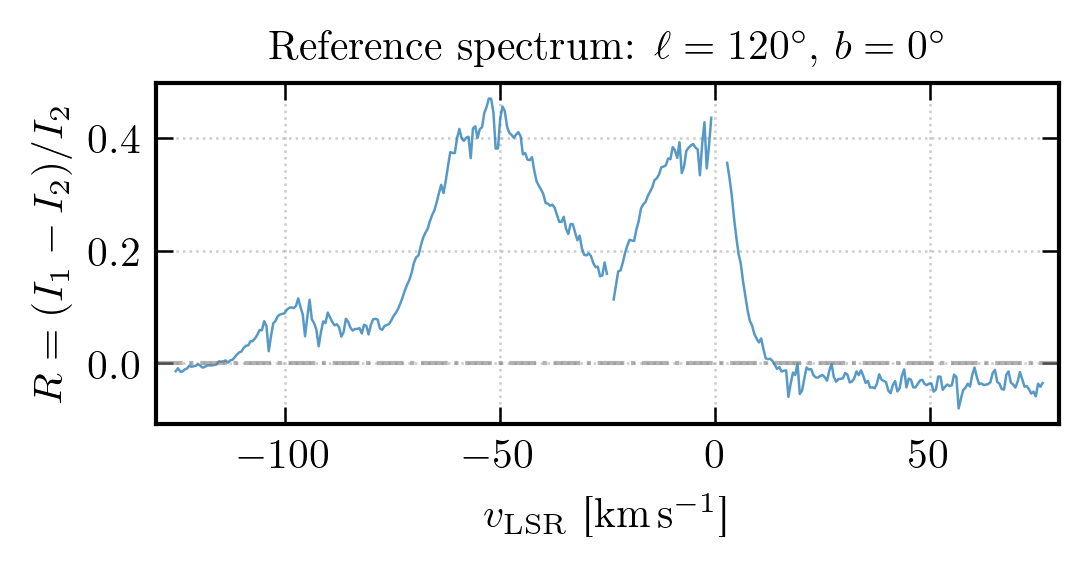

In [57]:
ref_idx = np.where((cell_keys[:, 0] == 120) & (cell_keys[:, 1] == 0))[0]

if len(ref_idx) == 0:
    print('WARNING: (l=120, b=0) not found in reduced data')
else:
    i = ref_idx[0]
    R_ref = R_stack[i]
    ax = plot_hi_spectrum(
        v_lsr, R_ref,
        title=r'Reference spectrum: $\ell=120^\circ$, $b=0^\circ$',
        ylabel=r'$R = (I_1 - I_2) / I_2$',
        xlabel=r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]',
        color='C0', ax=None,
    )
    ax.set_xlim(-130, 80)
    print(f'n_pairs = {n_pairs[i]}, SNR = {snr[i]:.1f}')
    plt.show()

## 3. Position-velocity diagrams

Longitude-velocity (l-v) cuts at selected latitudes.

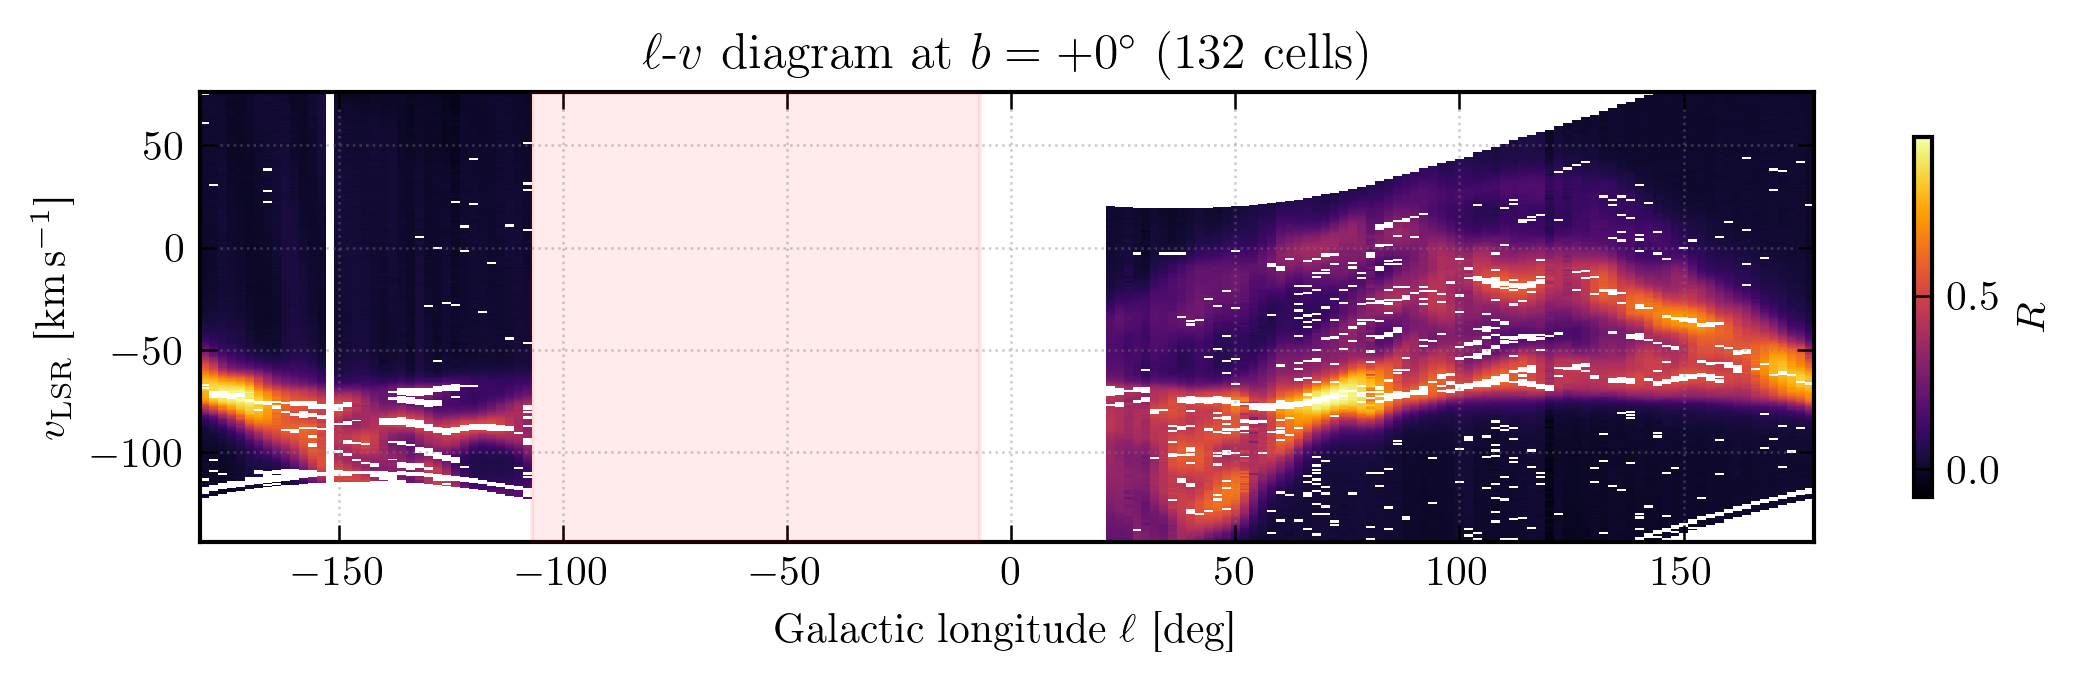

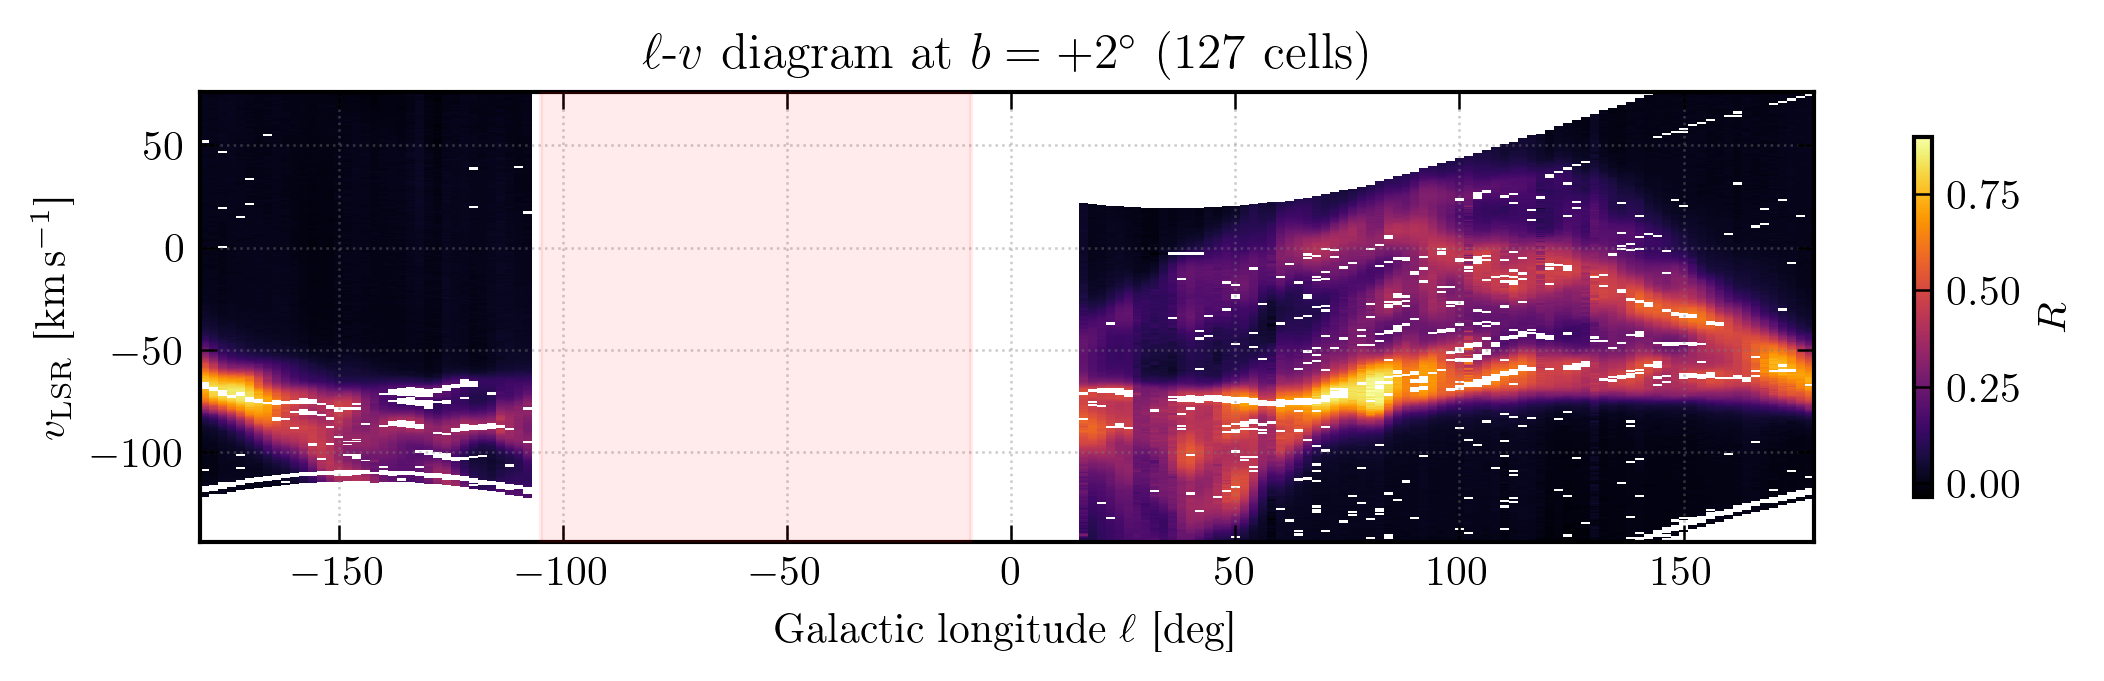

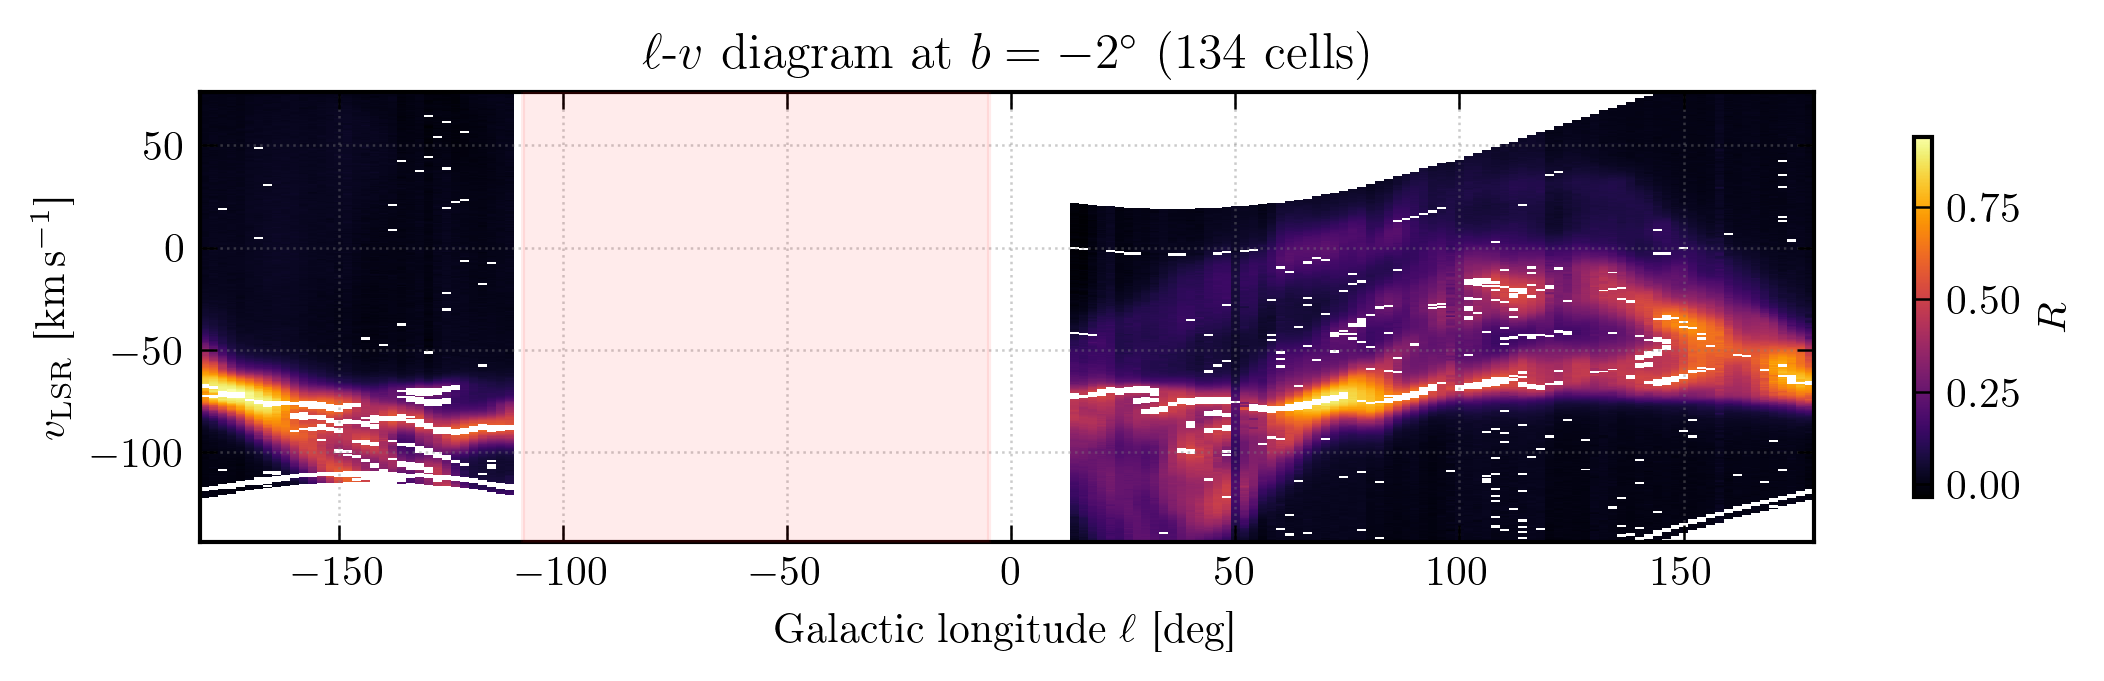

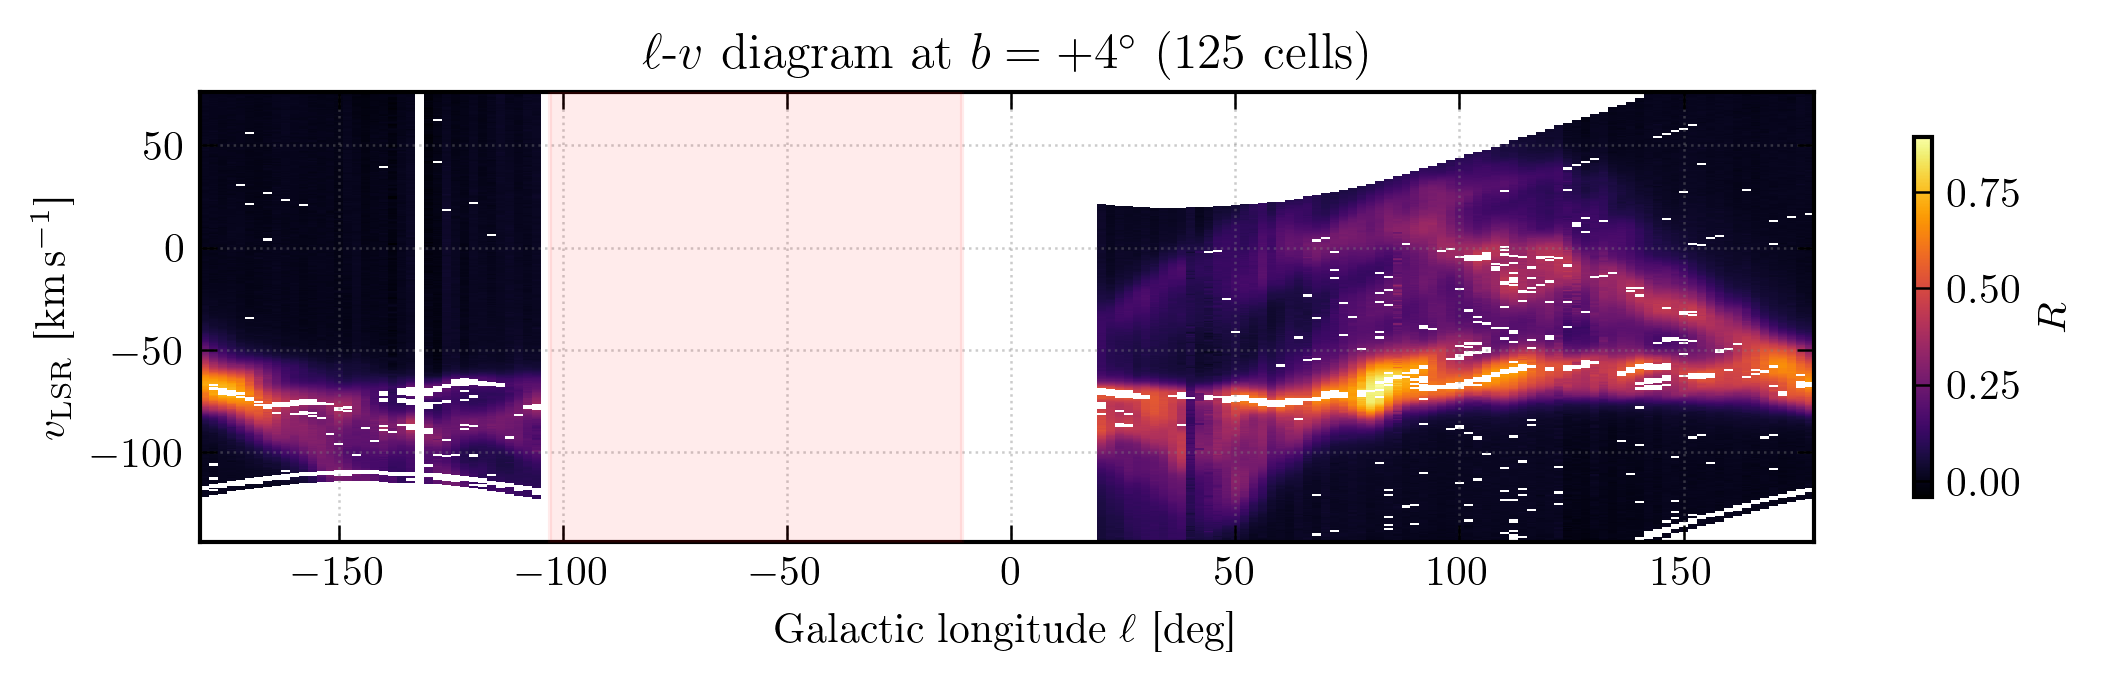

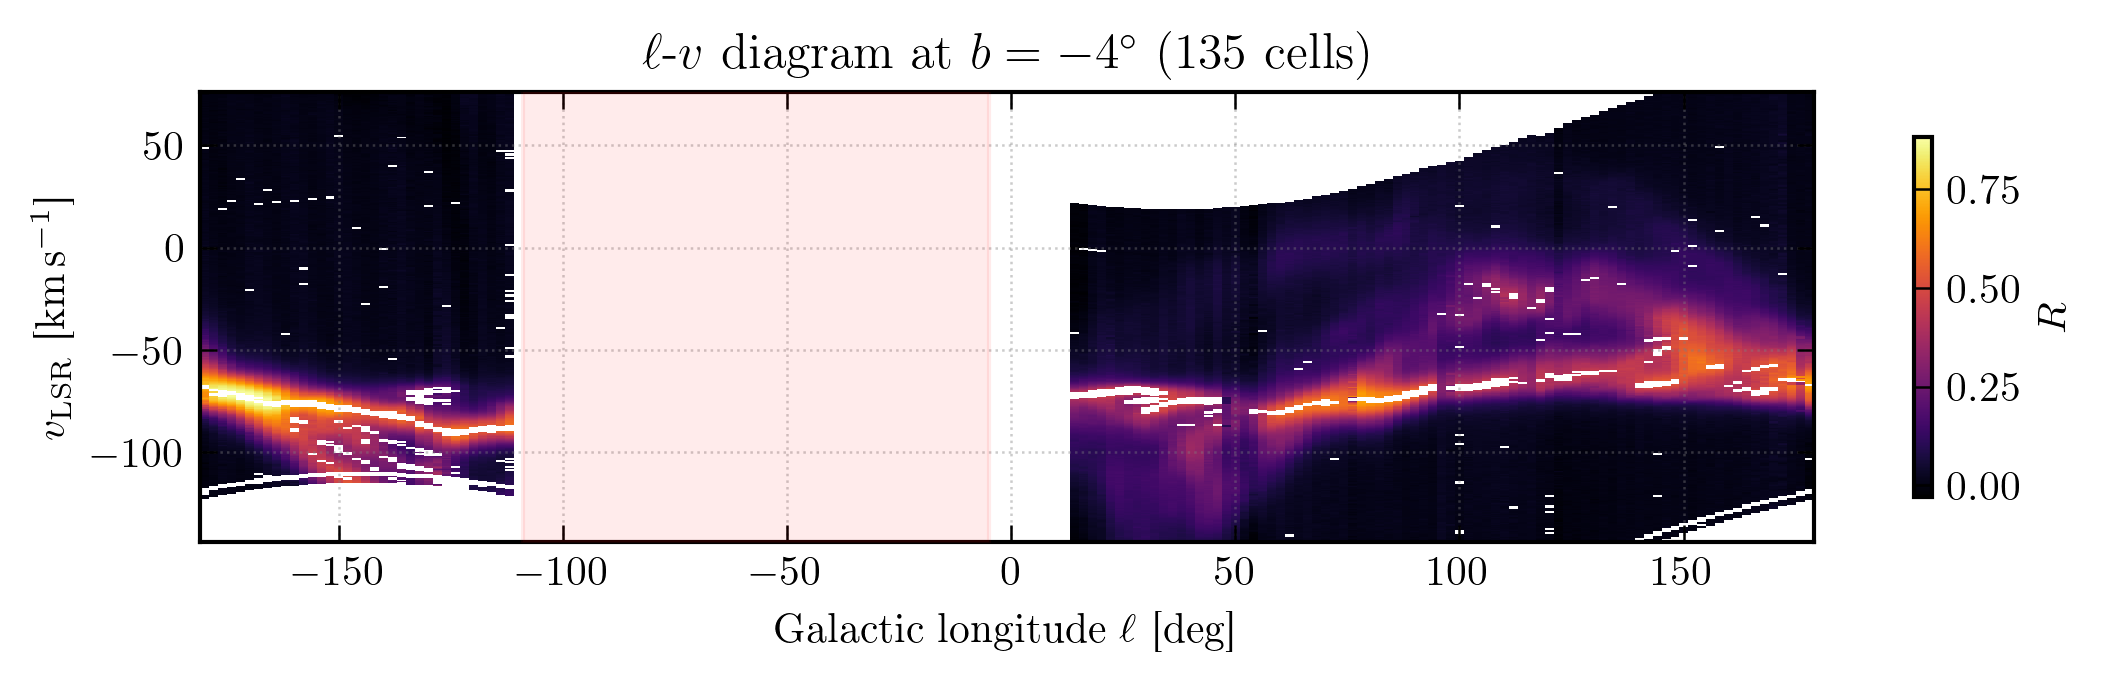

In [58]:
import astropy.coordinates as ac
import astropy.units as u_ast
import matplotlib as mpl

LEO_LAT_RAD = np.deg2rad(37.9183)
MIN_ALT_RAD = np.deg2rad(17.0)
MAX_ALT_RAD = np.deg2rad(83.0)
AZ_MIN_RAD = np.deg2rad(7.0)
AZ_MAX_RAD = np.deg2rad(348.0)
HA_STEPS = np.deg2rad(np.arange(0, 360, 1))


def never_observable_mask(l_arr, b_val):
    """Return a boolean array: True where (l, b_val) is never observable."""
    gc = ac.SkyCoord(l=l_arr * u_ast.deg,
                     b=np.full_like(l_arr, b_val, dtype=float) * u_ast.deg,
                     frame='galactic')
    dec_rad = np.deg2rad(gc.transform_to(ac.ICRS()).dec.deg)

    observable = np.zeros(len(l_arr), dtype=bool)
    for ha in HA_STEPS:
        sin_alt = (np.sin(LEO_LAT_RAD) * np.sin(dec_rad)
                   + np.cos(LEO_LAT_RAD) * np.cos(dec_rad) * np.cos(ha))
        alt = np.arcsin(np.clip(sin_alt, -1, 1))
        cos_az_num = np.sin(dec_rad) - np.sin(LEO_LAT_RAD) * sin_alt
        cos_az_den = np.cos(LEO_LAT_RAD) * np.cos(alt)
        with np.errstate(invalid='ignore', divide='ignore'):
            cos_az = np.clip(cos_az_num / cos_az_den, -1, 1)
        az = np.arccos(cos_az)
        az = np.where(np.sin(ha) > 0, 2 * np.pi - az, az)
        observable |= ((alt >= MIN_ALT_RAD) & (alt <= MAX_ALT_RAD)
                       & (az >= AZ_MIN_RAD) & (az <= AZ_MAX_RAD))
    return ~observable


b_cuts = [0, 2, -2, 4, -4]

for b_cut in b_cuts:
    sel = np.where((cell_keys[:, 1] == b_cut) & clean)[0]
    if len(sel) < 3:
        continue

    # Wrap longitude to [-180, 180) so l=0 (Galactic Center) is at the center
    l_wrapped = ((cell_keys[sel, 0] + 180) % 360) - 180
    order = np.argsort(l_wrapped)
    sel = sel[order]
    l_wrapped = l_wrapped[order]

    # Build l-v image on a regular 2-deg grid
    l_unique = np.arange(l_wrapped.min(), l_wrapped.max() + 1, 2)
    lv_img = np.full((len(v_lsr), len(l_unique)), np.nan)
    for j, idx in enumerate(sel):
        li = np.searchsorted(l_unique, l_wrapped[j])
        if 0 <= li < len(l_unique):
            lv_img[:, li] = R_stack[idx]

    fig, ax = plotting.textwidth_figure(5)
    im = ax.imshow(
        lv_img, origin='lower', aspect='auto',
        extent=[l_unique[0] - 1, l_unique[-1] + 1, v_lsr[-1], v_lsr[0]],
        cmap='inferno', interpolation='nearest',
    )

    # Shade never-observable longitudes as contiguous hatched regions
    l_test = (l_unique.astype(float) % 360)
    inacc = never_observable_mask(l_test, float(b_cut))
    v_lo, v_hi = v_lsr[-1], v_lsr[0]
    first_patch = True
    # Find contiguous runs of inaccessible longitudes
    runs = []
    k = 0
    while k < len(l_unique):
        if inacc[k]:
            k0 = k
            while k < len(l_unique) and inacc[k]:
                k += 1
            runs.append((l_unique[k0] - 1, l_unique[k - 1] + 1))
        else:
            k += 1
    for l_lo, l_hi in runs:
        label = 'Never observable' if first_patch else None
        ax.fill_between([l_lo, l_hi], v_lo, v_hi,
                        color='red', alpha=0.08, zorder=3)
        with mpl.rc_context({'hatch.color': 'red', 'hatch.linewidth': 0.5}):
            ax.fill_between([l_lo, l_hi], v_lo, v_hi,
                            facecolor='none', edgecolor='none',
                            hatch='///', alpha=0.4, zorder=4,
                            label=label)
        first_patch = False

    ax.set_xlabel(r'Galactic longitude $\ell$ [deg]', fontsize=LABEL_SIZE)
    ax.set_ylabel(r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]', fontsize=LABEL_SIZE)
    ax.set_title(rf'$\ell$-$v$ diagram at $b = {b_cut:+d}^\circ$ '
                 rf'({len(sel)} cells)', fontsize=EMPHASIS_SIZE)
    plt.colorbar(im, ax=ax, label=r'$R$', shrink=0.8)
    plt.show()

## 4. Latitude-velocity slices

b-v cuts at selected longitudes.

In [59]:
# l_cuts = [120, 80, 40, 180, 220]

# for l_cut in l_cuts:
#     sel = np.where((cell_keys[:, 0] == l_cut) & clean)[0]
#     if len(sel) < 3:
#         continue

#     order = np.argsort(cell_keys[sel, 1])
#     sel = sel[order]
#     b_vals = cell_keys[sel, 1]

#     b_unique = np.arange(b_vals.min(), b_vals.max() + 1, 2)
#     bv_img = np.full((len(v_lsr), len(b_unique)), np.nan)
#     for j, idx in enumerate(sel):
#         bi = np.searchsorted(b_unique, cell_keys[idx, 1])
#         if 0 <= bi < len(b_unique):
#             bv_img[:, bi] = R_stack[idx]

#     fig, ax = plotting.textwidth_figure(5)
#     im = ax.imshow(
#         bv_img, origin='lower', aspect='auto',
#         extent=[b_unique[0] - 1, b_unique[-1] + 1, v_lsr[-1], v_lsr[0]],
#         cmap='inferno', interpolation='nearest',
#     )
#     ax.set_xlabel(r'Galactic latitude $b$ [deg]', fontsize=LABEL_SIZE)
#     ax.set_ylabel(r'$v_{\mathrm{LSR}}$ [km\,s$^{-1}$]', fontsize=LABEL_SIZE)
#     ax.set_title(rf'$b$-$v$ diagram at $\ell = {l_cut}^\circ$ '
#                  rf'({len(sel)} cells)', fontsize=EMPHASIS_SIZE)
#     plt.colorbar(im, ax=ax, label=r'$R$', shrink=0.8)
#     plt.show()

## 5. Integrated intensity map W(l, b)

Mollweide projection of velocity-integrated R.

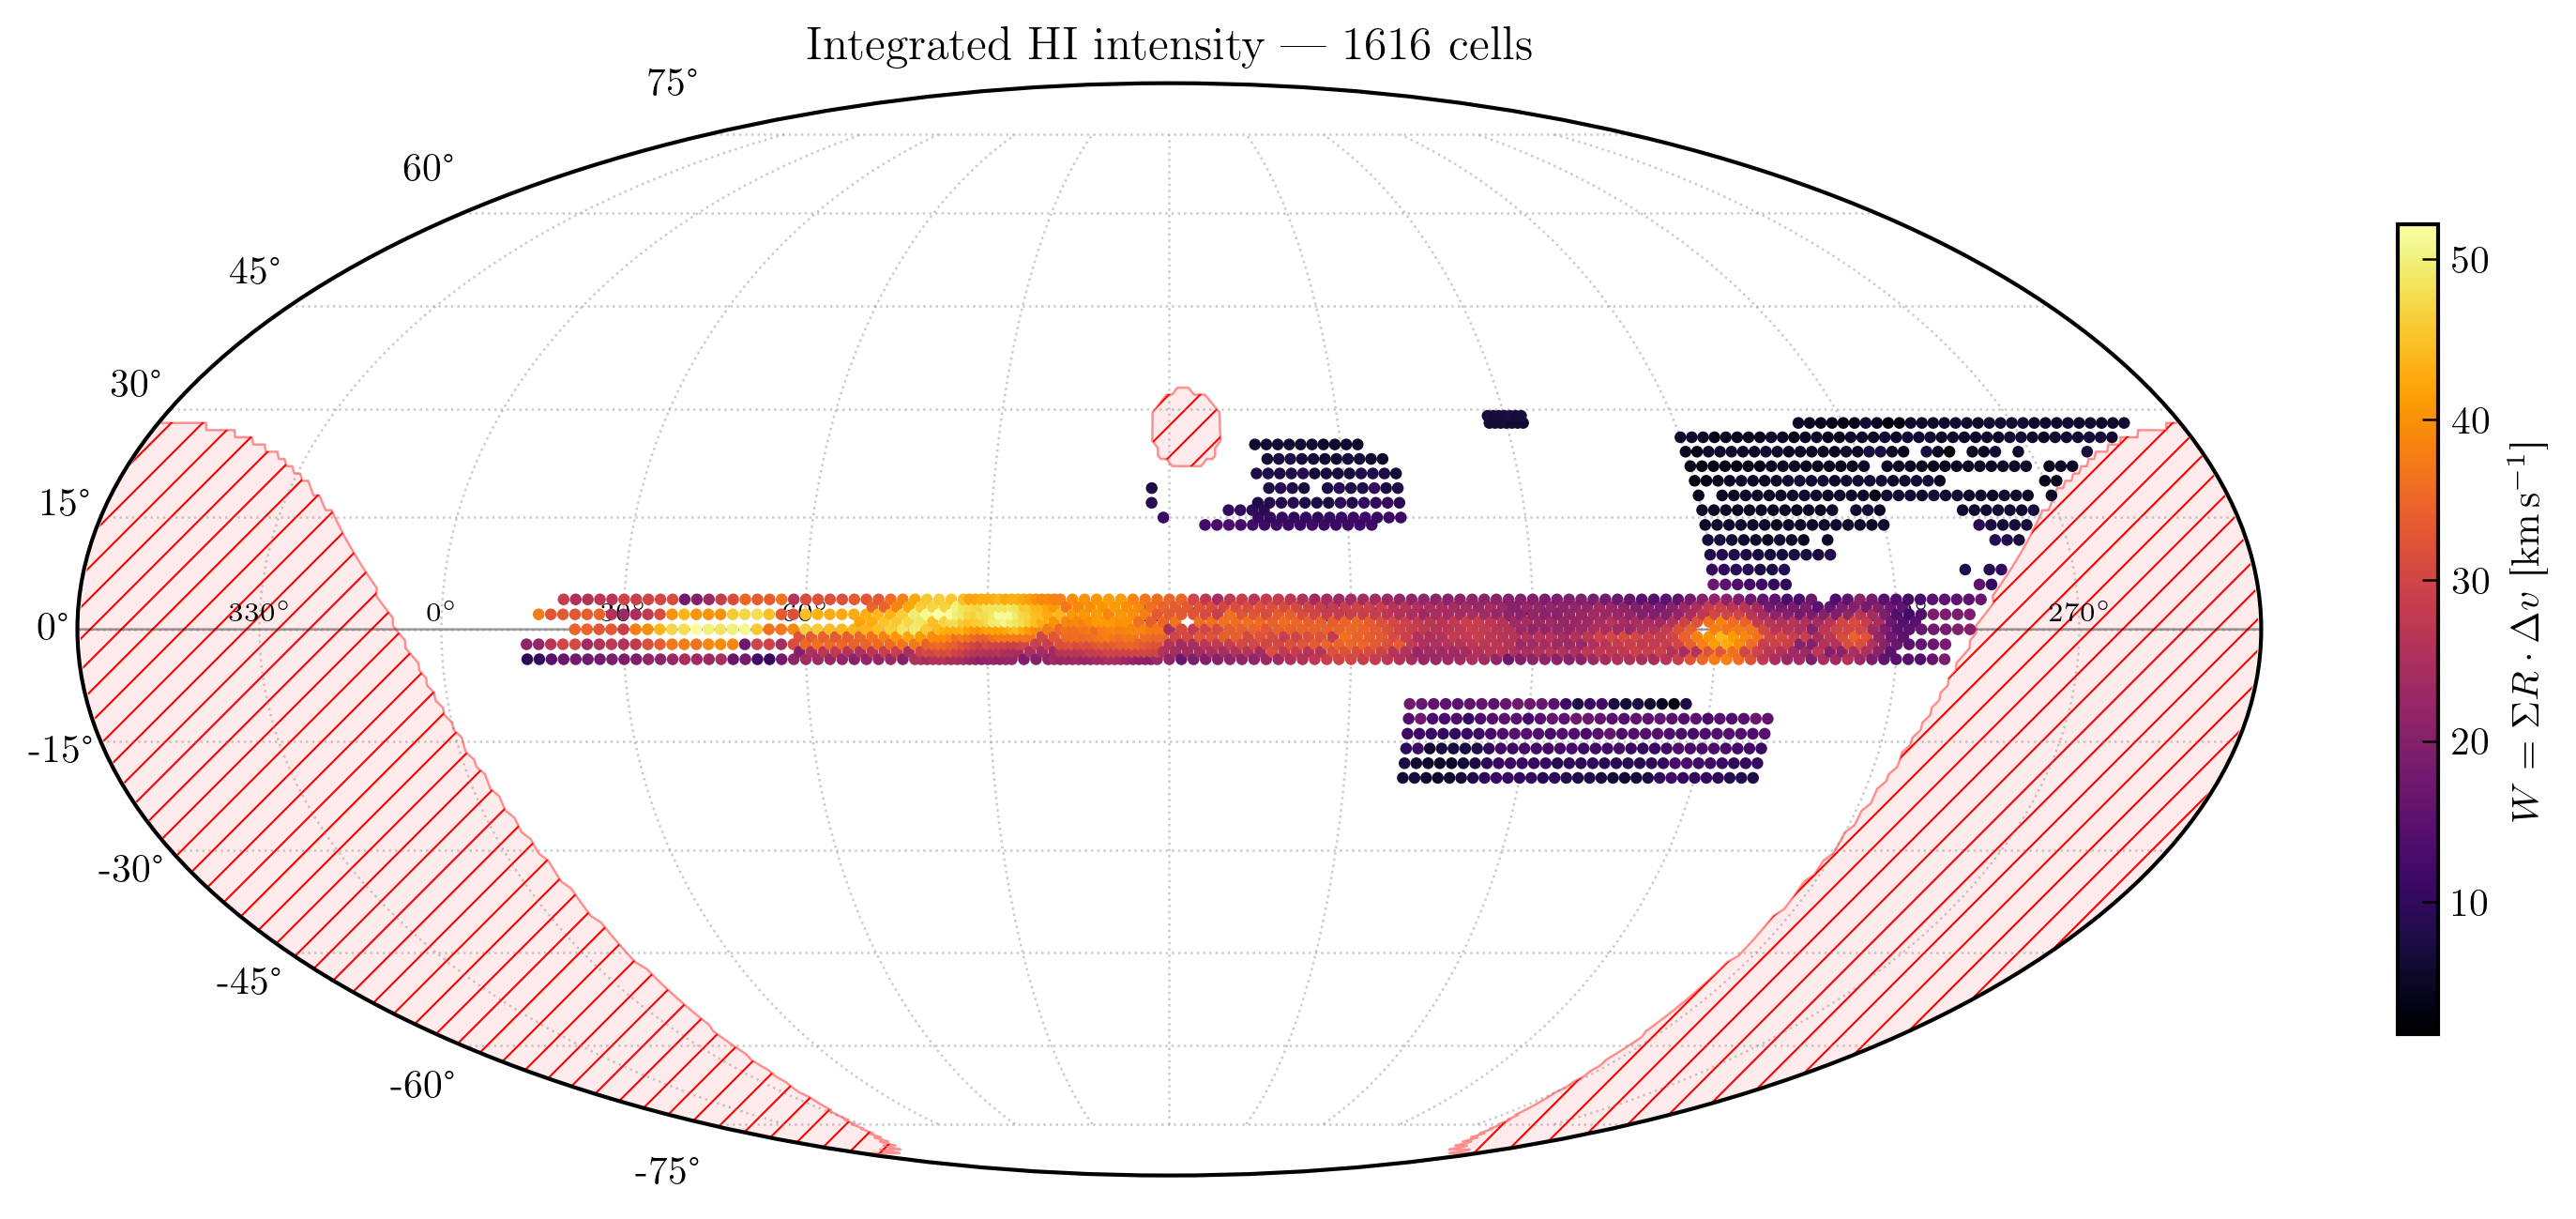

In [60]:
fig, ax = plot_survey_mollweide(
    gl[clean], gb[clean], W[clean],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \Sigma R \cdot \Delta v$ [km\,s$^{-1}$]',
    cmap='inferno',
    marker_size=SS_FINE,
    title=f'Integrated HI intensity --- {clean.sum()} cells',
)
plt.show()

## 6. Peak velocity map v_peak(l, b)

Mollweide projection of peak LSR velocity.

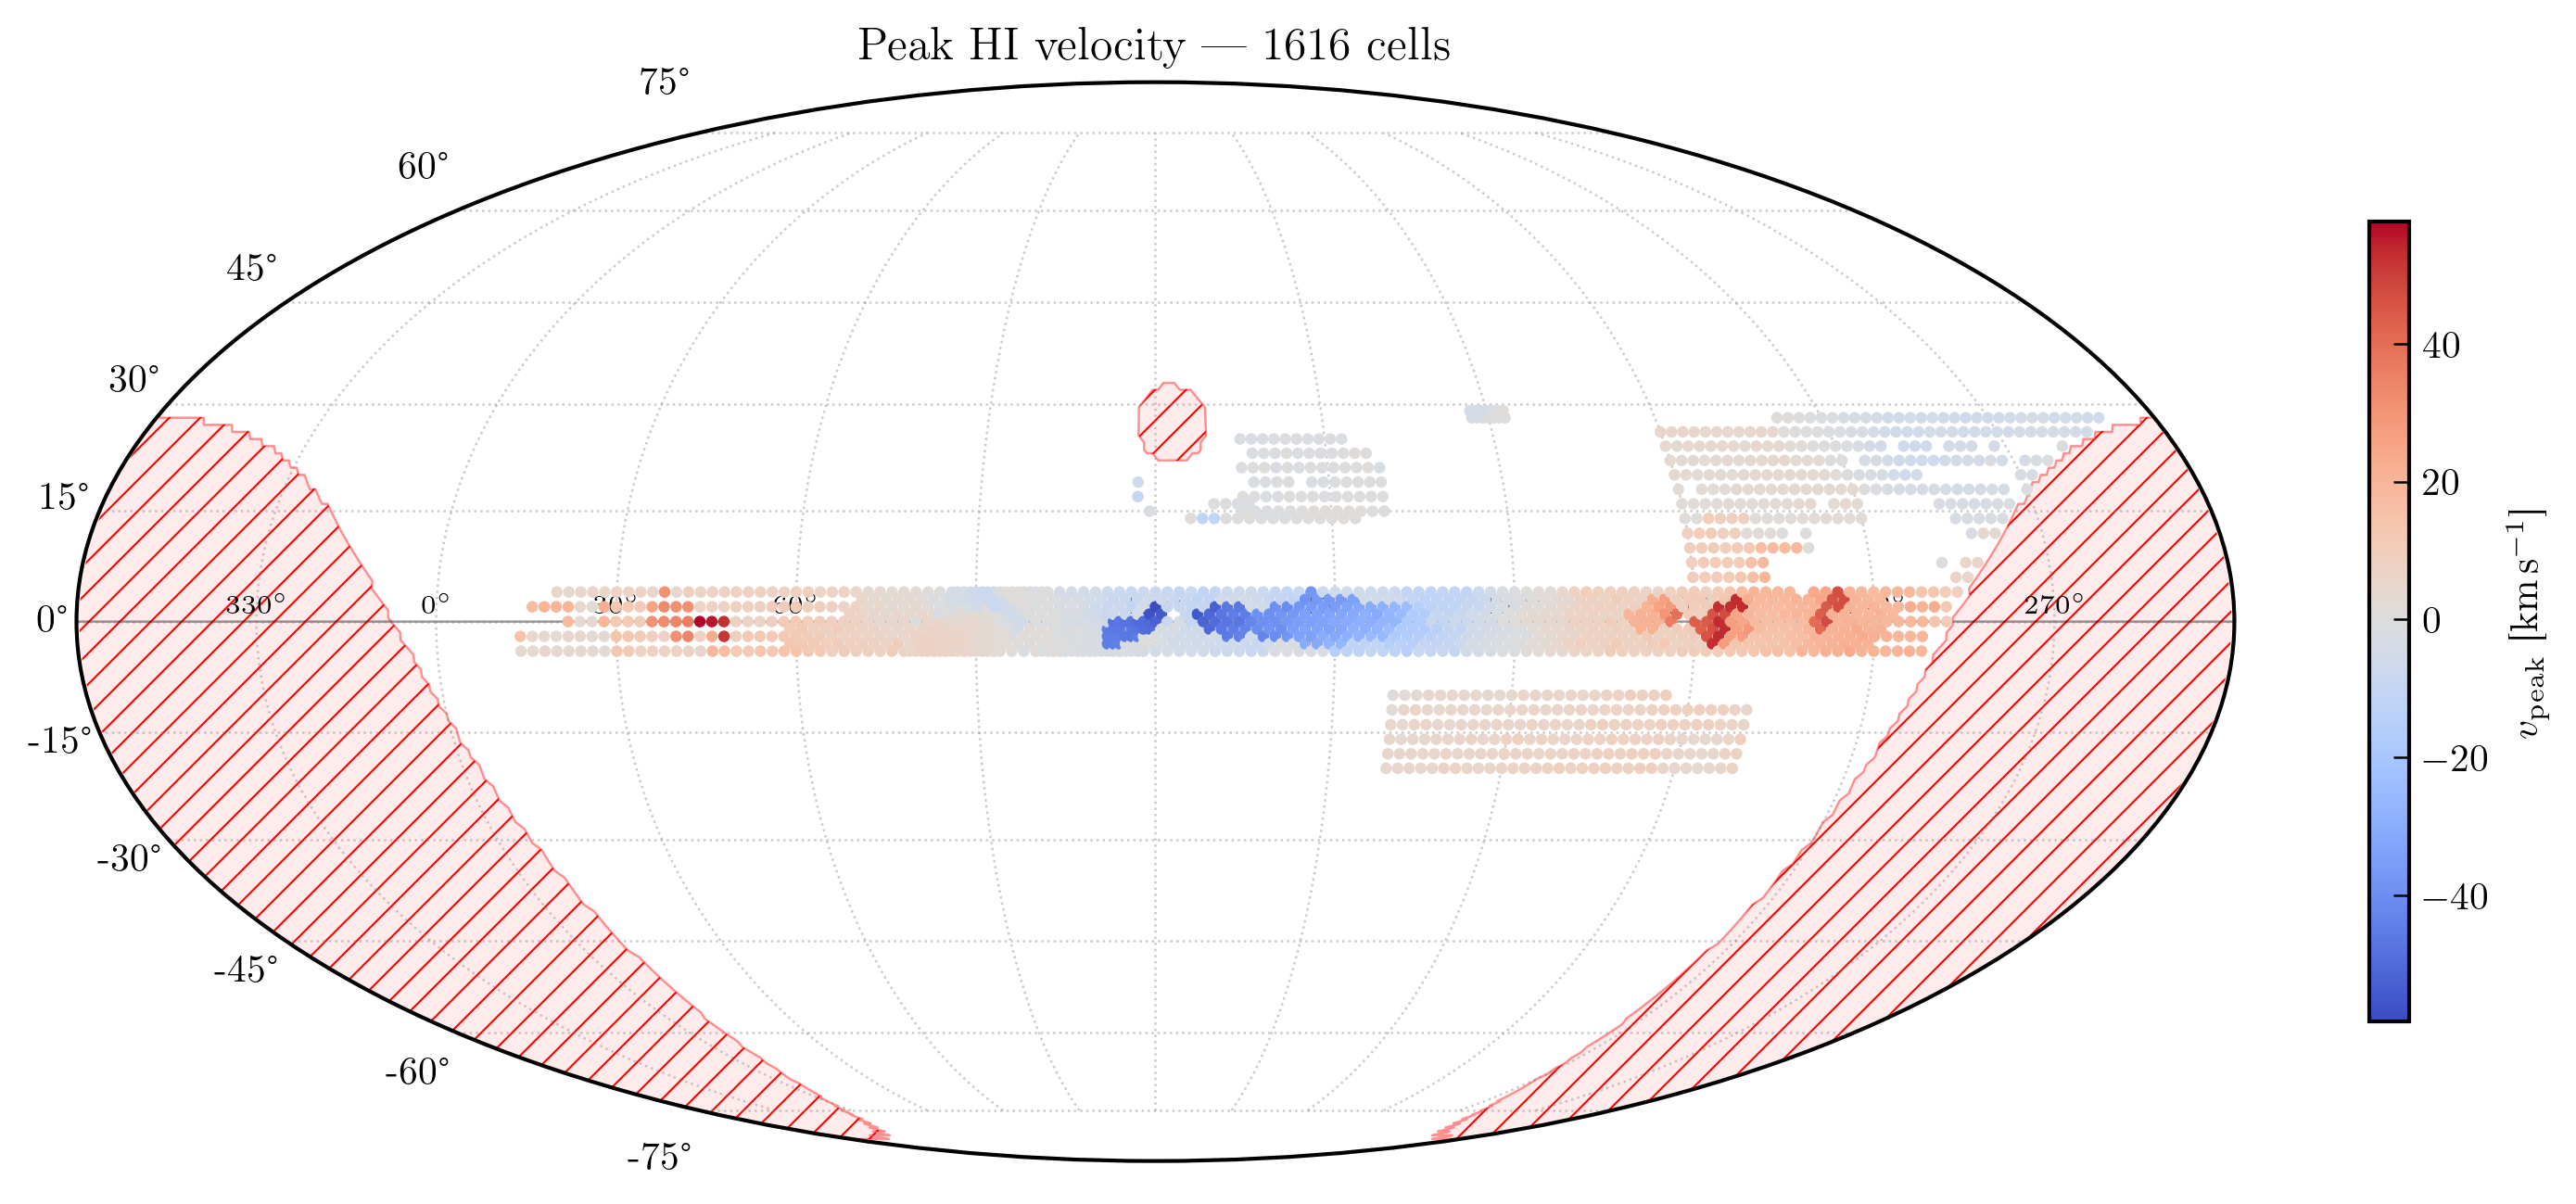

In [61]:
fig, ax = plot_survey_mollweide(
    gl[clean], gb[clean], peak_v[clean],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$v_{\mathrm{peak}}$ [km\,s$^{-1}$]',
    cmap='coolwarm',
    marker_size=SS_FINE,
    title=f'Peak HI velocity --- {clean.sum()} cells',
)
plt.show()

## 7. Channel maps

Spatial maps of R at selected velocity slices.

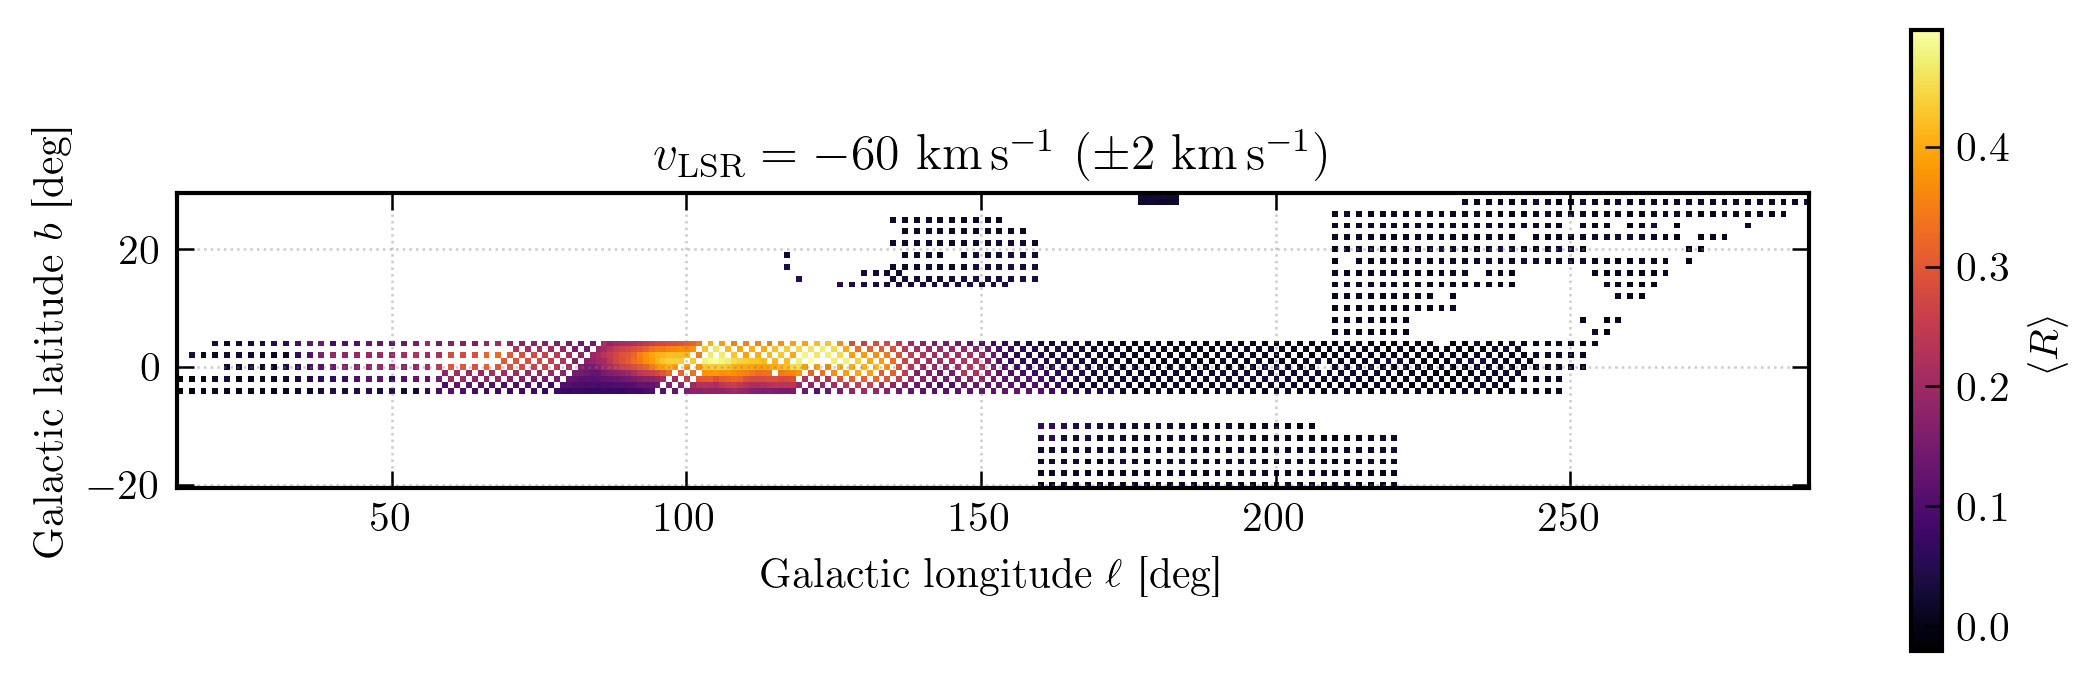

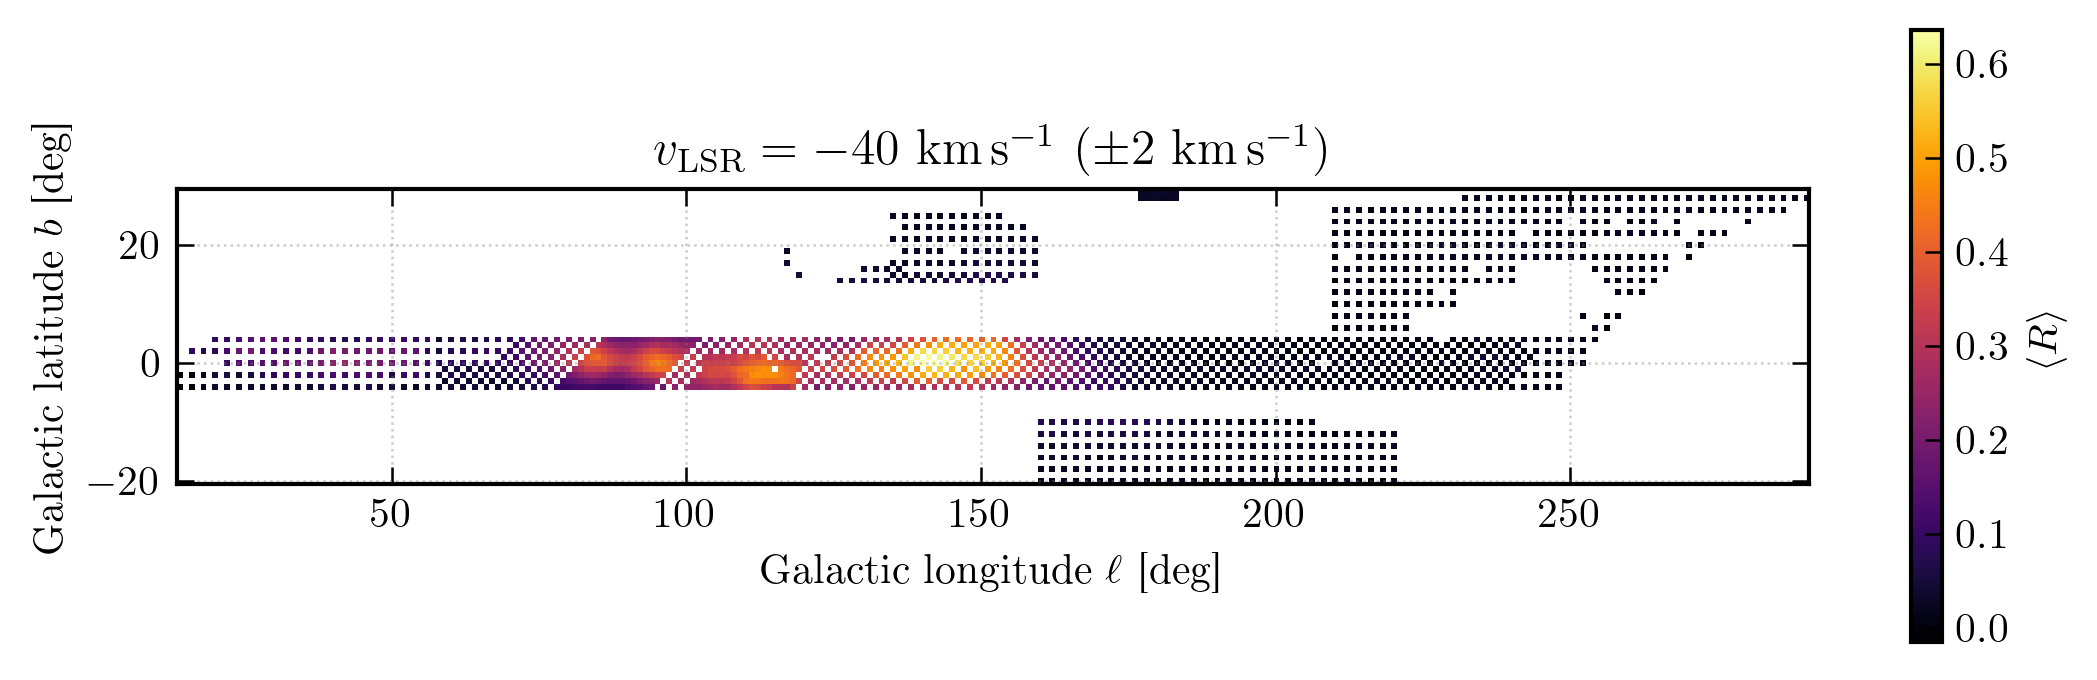

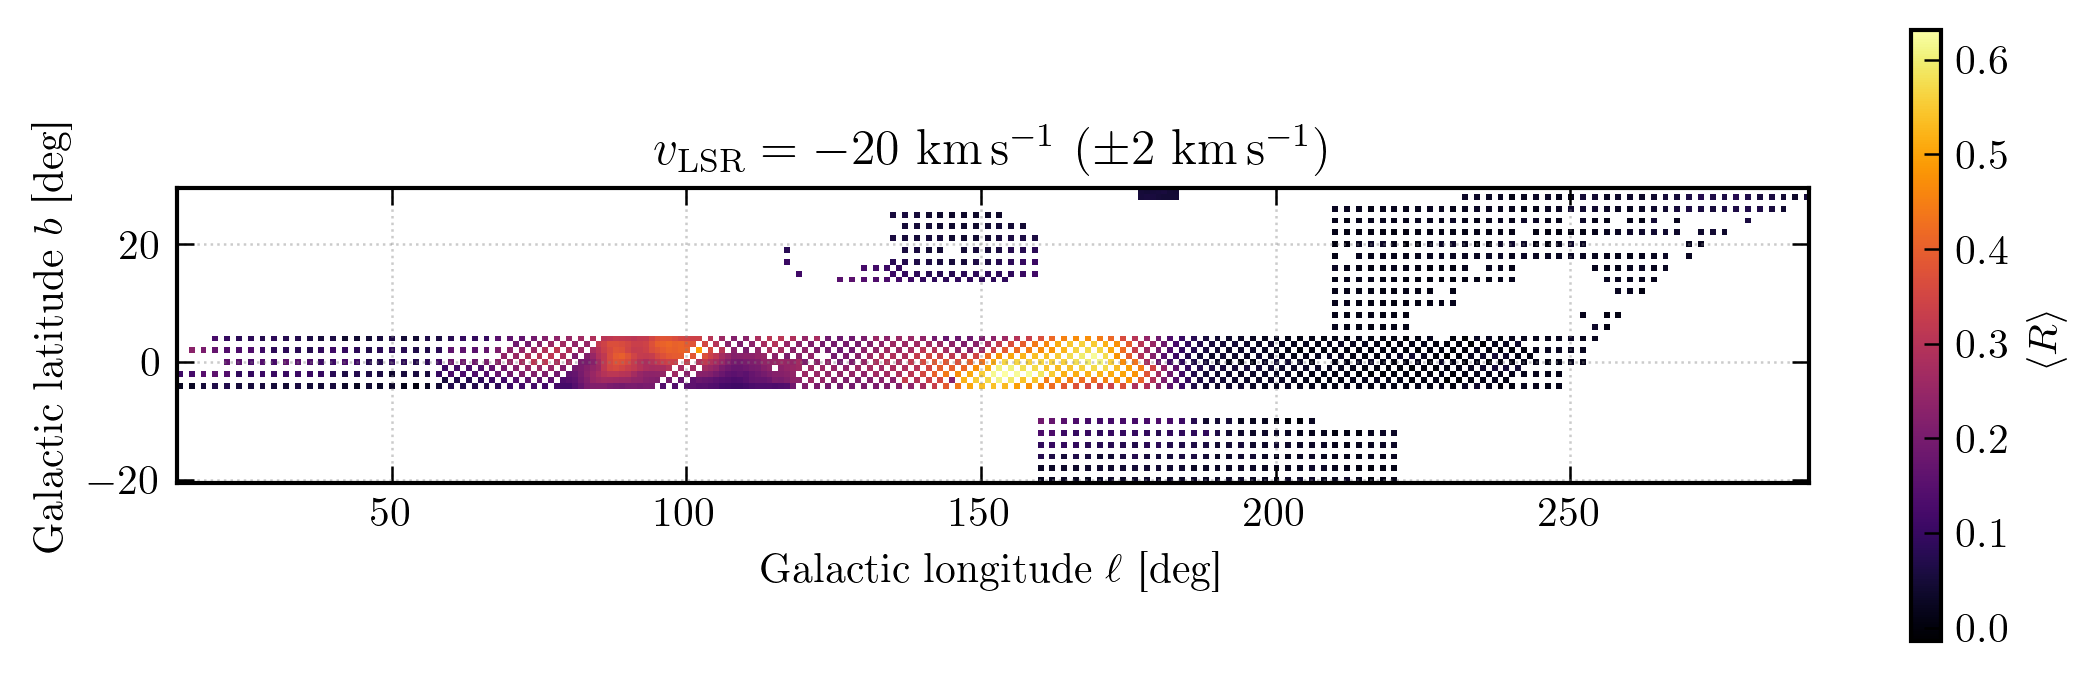

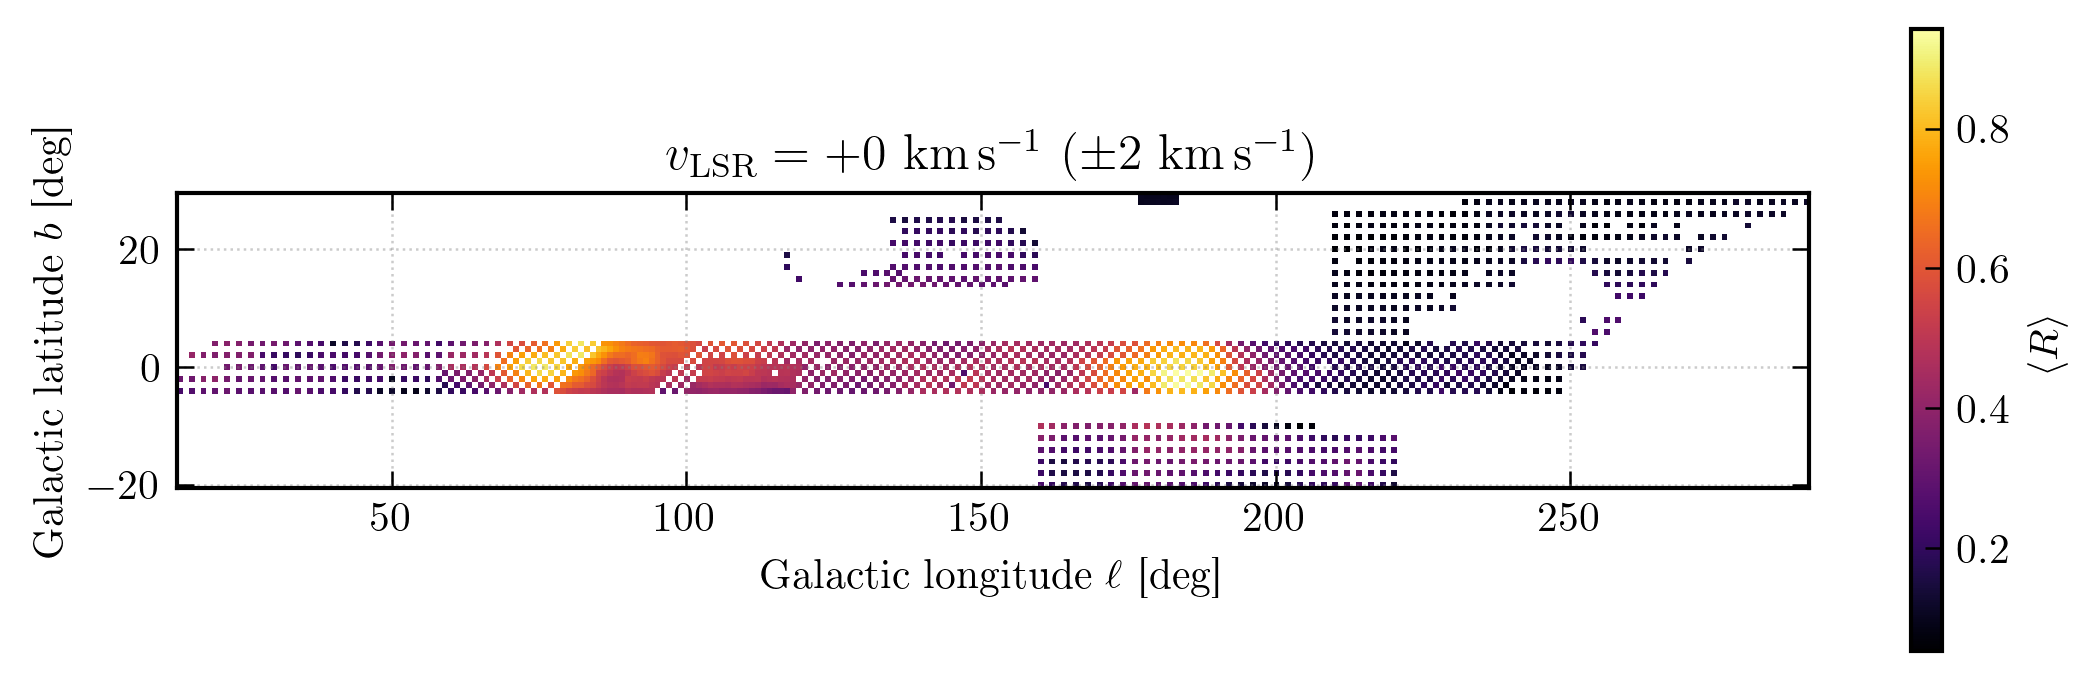

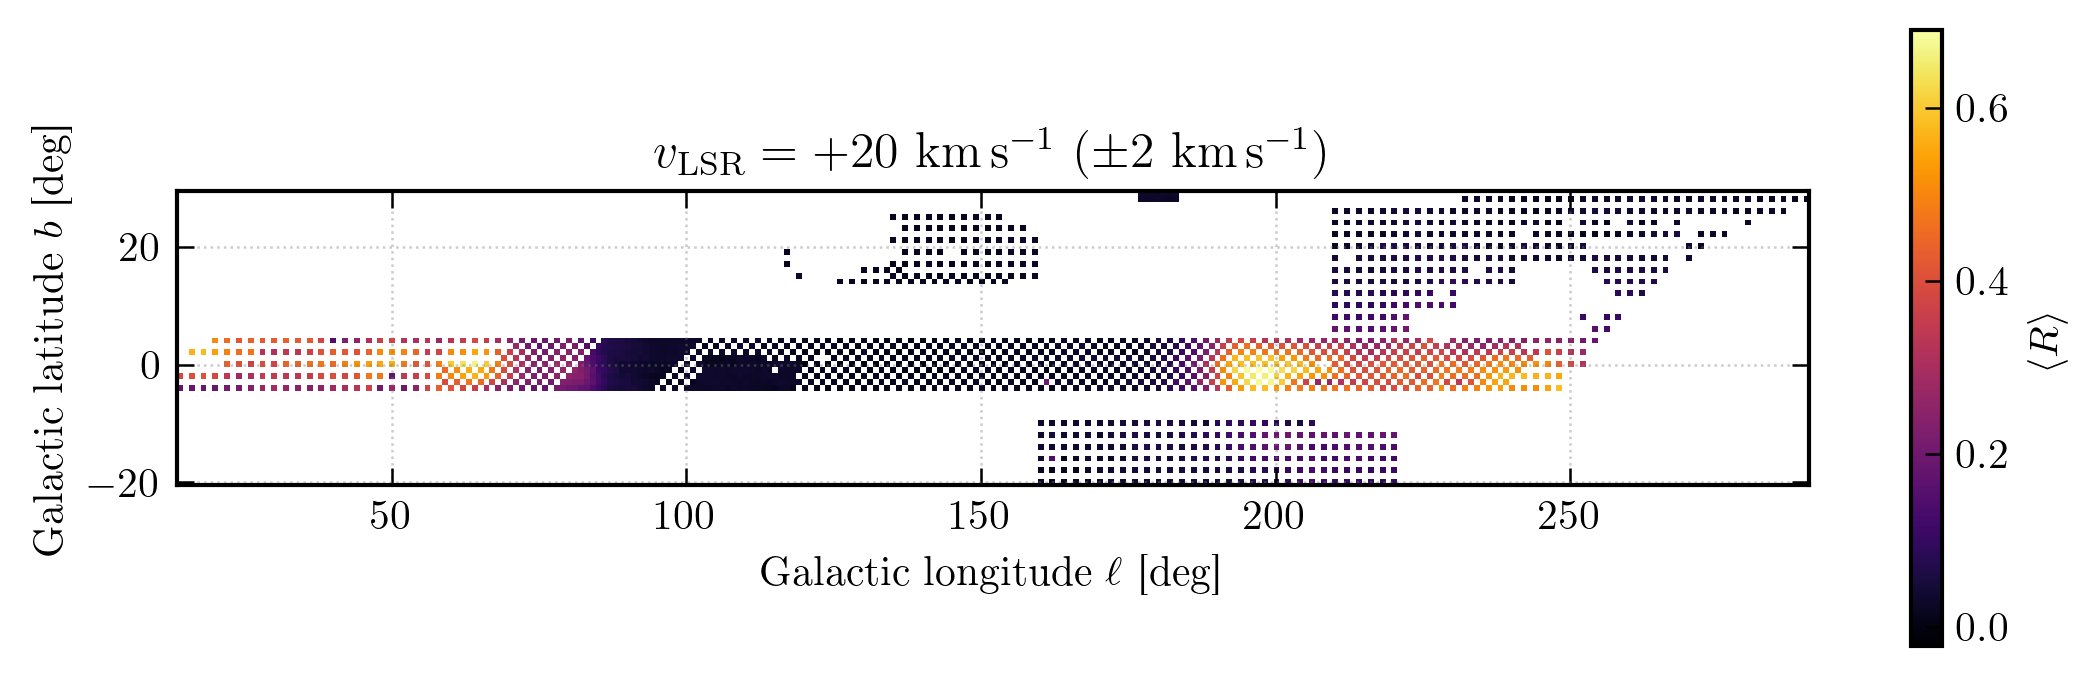

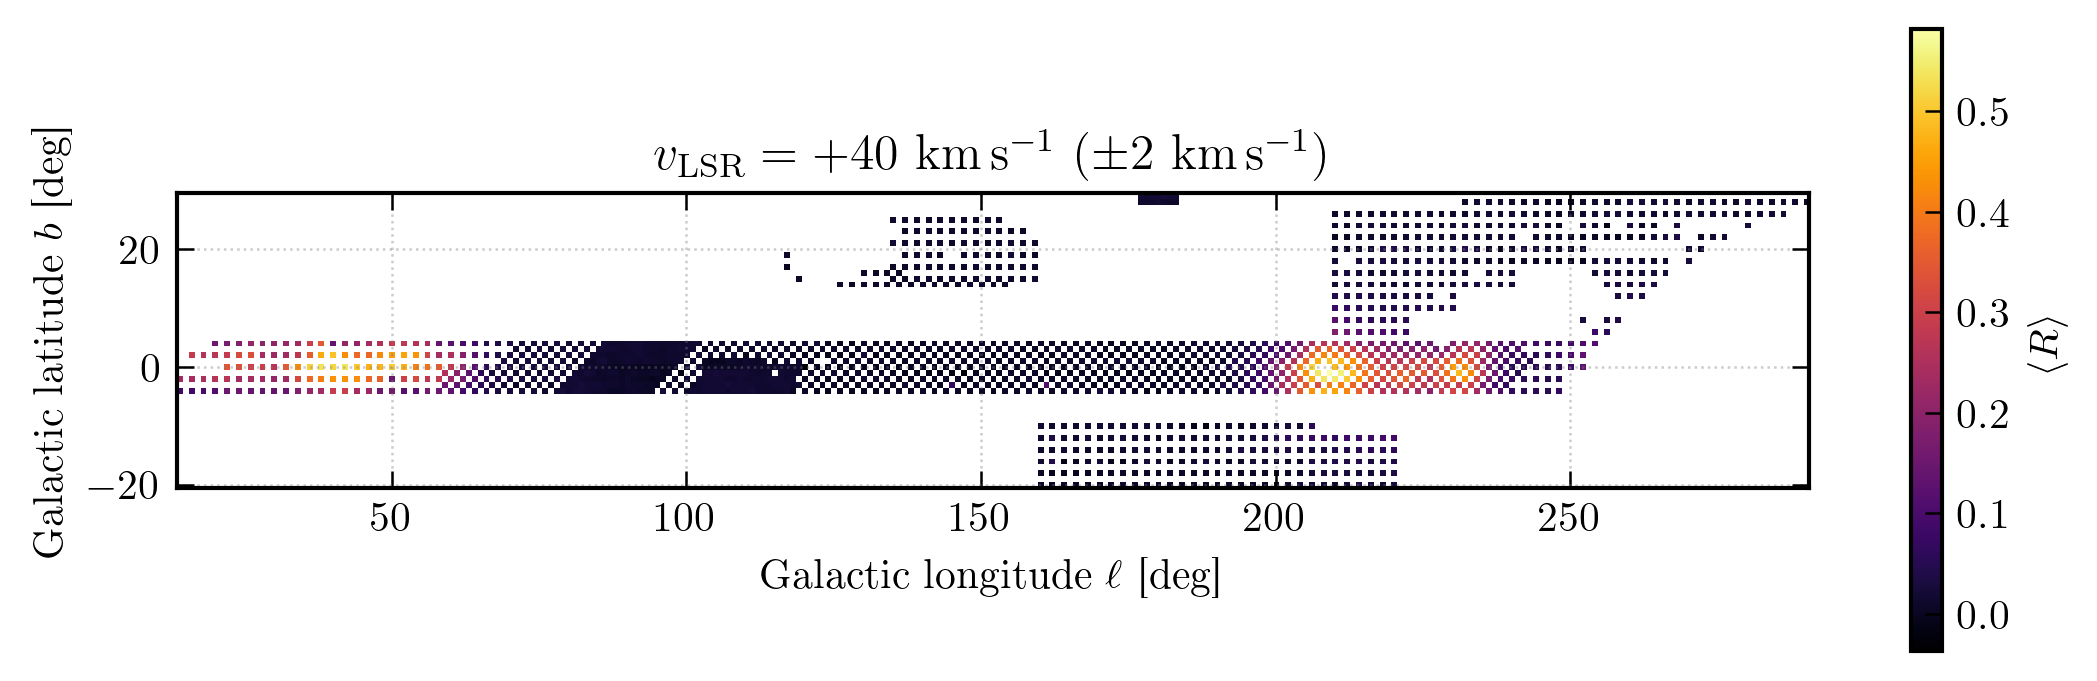

In [62]:
v_slices_kms = [-60, -40, -20, 0, 20, 40]

for v_target in v_slices_kms:
    # Average over a 5 km/s window centered on v_target
    v_window = 5.0
    ch_mask = (v_lsr >= v_target - v_window / 2) & (v_lsr <= v_target + v_window / 2)
    if ch_mask.sum() == 0:
        continue

    R_slice = np.nanmean(R_stack[clean][:, ch_mask], axis=1)

    fig, ax = plot_heatmap(
        gl[clean], gb[clean], R_slice,
        cbar_label=r'$\langle R \rangle$',
        cmap='inferno',
        title=rf'$v_{{\mathrm{{LSR}}}} = {v_target:+d}$ km\,s$^{{-1}}$ '
              rf'($\pm${v_window/2:.0f} km\,s$^{{-1}}$)',
    )
    plt.show()

## 8. Face-on Milky Way map

Deproject the b=0 l-v diagram into the Galactic plane using the
kinematic distance method with a flat rotation curve.

For each (l, v_LSR) pixel the line-of-sight velocity constrains the
galactocentric radius R via

$$v_{\mathrm{LSR}} = R_0 \sin\ell \left[\frac{V(R)}{R} - \frac{V_0}{R_0}\right]$$

where V(R) = V_0 (flat curve).  In the inner Galaxy (|l| < 90) there
is a near/far distance ambiguity; both solutions are plotted.

21954 (x, y) points from 132 sightlines


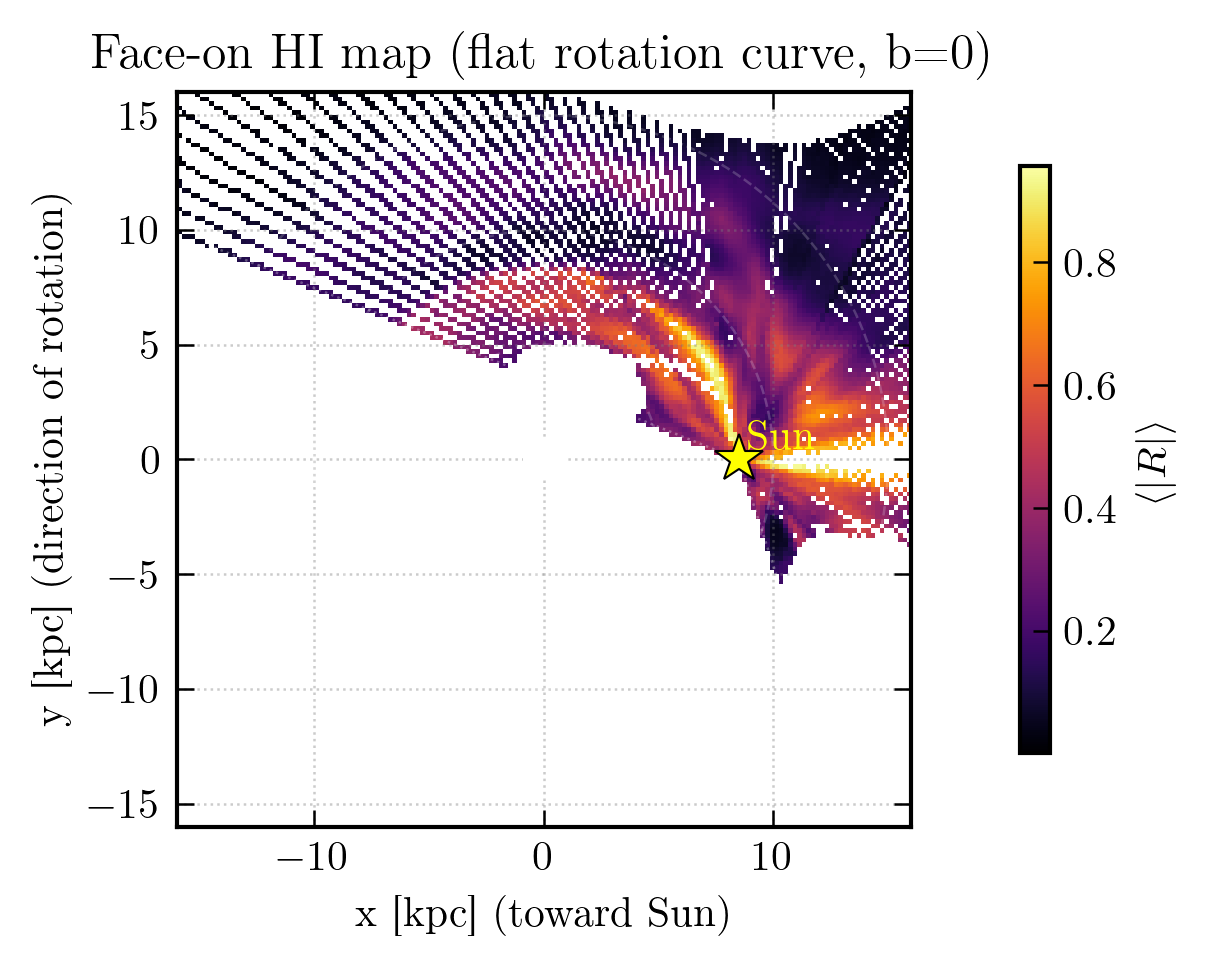

Grid: 0.2 kpc resolution, 160x160 pixels
R_0 = 8.5 kpc, V_0 = 220.0 km/s (flat rotation curve)
Longitude coverage: l = 22 to 252 deg


In [63]:
# IAU standard rotation curve parameters
R_0 = 8.5    # kpc, Sun-GC distance
V_0 = 220.0  # km/s, circular velocity (flat curve)

# Use b=0 slice (largest longitude coverage)
b_cut = 0
sel = np.where((cell_keys[:, 1] == b_cut) & clean)[0]
order = np.argsort(cell_keys[sel, 0])
sel = sel[order]
l_all = cell_keys[sel, 0].astype(float)

# Collect (x, y, brightness) for every (l, v) pixel with signal
xy_points = []

for idx in sel:
    l_deg = float(cell_keys[idx, 0])
    l_rad = np.deg2rad(l_deg)
    sin_l = np.sin(l_rad)
    cos_l = np.cos(l_rad)

    # Skip l ~ 0 and l ~ 180 where sin(l) ~ 0 (no radial velocity)
    if abs(sin_l) < np.sin(np.deg2rad(5)):
        continue

    R_spec = R_stack[idx]

    for ch in range(len(v_lsr)):
        v = v_lsr[ch]
        R_val = R_spec[ch]
        if not np.isfinite(R_val):
            continue

        # Solve for galactocentric radius R from flat rotation curve:
        # v = R_0 sin(l) [V_0/R - V_0/R_0]
        # 1/R = v / (V_0 R_0 sin(l)) + 1/R_0
        denom = V_0 * R_0 * sin_l
        inv_R = v / denom + 1.0 / R_0

        if inv_R <= 0:
            continue
        R_gal = 1.0 / inv_R
        if R_gal < 0.5 or R_gal > 25.0:
            continue

        # Distance(s) from the Sun: d^2 - 2 R_0 cos(l) d + (R_0^2 - R^2) = 0
        b_coeff = -2.0 * R_0 * cos_l
        c_coeff = R_0**2 - R_gal**2
        disc = b_coeff**2 - 4.0 * c_coeff

        if disc < 0:
            continue

        sqrt_disc = np.sqrt(disc)
        d_near = (-b_coeff - sqrt_disc) / 2.0
        d_far = (-b_coeff + sqrt_disc) / 2.0

        for d in [d_near, d_far]:
            if d < 0.1:
                continue
            # Galactocentric Cartesian: Sun at (R_0, 0), GC at origin
            x = R_0 - d * cos_l
            y = d * sin_l
            if abs(x) < 20 and abs(y) < 20:
                xy_points.append((x, y, abs(R_val)))

print(f'{len(xy_points)} (x, y) points from {len(sel)} sightlines')

# Grid onto a 2D image
GRID_RES = 0.2  # kpc
GRID_HALF = 16  # kpc from center
n_bins = int(2 * GRID_HALF / GRID_RES)

grid_sum = np.zeros((n_bins, n_bins))
grid_cnt = np.zeros((n_bins, n_bins))

for x, y, brightness in xy_points:
    xi = int((x + GRID_HALF) / GRID_RES)
    yi = int((y + GRID_HALF) / GRID_RES)
    if 0 <= xi < n_bins and 0 <= yi < n_bins:
        grid_sum[yi, xi] += brightness
        grid_cnt[yi, xi] += 1

with np.errstate(invalid='ignore'):
    grid_mean = np.where(grid_cnt > 0, grid_sum / grid_cnt, np.nan)

# Plot
fig, ax = plotting.textwidth_figure(7)
im = ax.imshow(
    grid_mean, origin='lower', aspect='equal',
    extent=[-GRID_HALF, GRID_HALF, -GRID_HALF, GRID_HALF],
    cmap='inferno',
)

# Mark Sun and Galactic Center
ax.plot(R_0, 0, '*', color='yellow', ms=12, mec='k', mew=0.5, zorder=10)
ax.annotate('Sun', (R_0 + 0.4, 0.4), color='yellow', fontsize=TICK_SIZE,
            fontweight='bold', zorder=10)
ax.plot(0, 0, '+', color='white', ms=10, mew=2, zorder=10)
ax.annotate('GC', (0.4, 0.4), color='white', fontsize=TICK_SIZE,
            fontweight='bold', zorder=10)

# Reference circles
for r in [5, 10, 15]:
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(r * np.cos(theta), r * np.sin(theta),
            ls='--', lw=LW_FINE, color='white', alpha=0.2)

# Sightline boundaries
for l_edge in [l_all.min(), l_all.max()]:
    l_rad = np.deg2rad(l_edge)
    d_line = np.linspace(0, 25, 200)
    x_line = R_0 - d_line * np.cos(l_rad)
    y_line = d_line * np.sin(l_rad)
    mask = (np.abs(x_line) < GRID_HALF) & (np.abs(y_line) < GRID_HALF)
    ax.plot(x_line[mask], y_line[mask], ls=':', lw=LW_FINE,
            color='white', alpha=0.3)

ax.set_xlabel('x [kpc]  (toward Sun)', fontsize=LABEL_SIZE)
ax.set_ylabel('y [kpc]  (direction of rotation)', fontsize=LABEL_SIZE)
ax.set_title('Face-on HI map (flat rotation curve, b=0)',
             fontsize=EMPHASIS_SIZE)
ax.set_xlim(-GRID_HALF, GRID_HALF)
ax.set_ylim(-GRID_HALF, GRID_HALF)
plt.colorbar(im, ax=ax, label=r'$\langle |R| \rangle$', shrink=0.8)
plt.show()

print(f'Grid: {GRID_RES} kpc resolution, {n_bins}x{n_bins} pixels')
print(f'R_0 = {R_0} kpc, V_0 = {V_0} km/s (flat rotation curve)')
print(f'Longitude coverage: l = {l_all.min():.0f} to {l_all.max():.0f} deg')